### Notebook 22

# **Cross-Validation Tables and Figures**

## **1. Tables**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import pickle

In [2]:
# Define the results path. 
results_path = '../neuropolis-x1_results/'

In [3]:
# Load the general results. 
with open(results_path + 'cross_validation/general_results.p', 'rb') as file:
    general_results = pickle.load(file)

# Store the results into variables corresponding to the dictionary keys. 
for key, value in general_results.items():
    globals()[key] = value

In [4]:
# Define a function to format the summary DataFrame. 
def format_df_summary(df_summary, score_type):

    # Copy the DataFrame. 
    df_summary_table = df_summary.copy()
    
    # Round values to 3 decimal places. 
    df_summary_table['mean model ' + score_type] = df_summary_table['mean model ' + score_type].astype(float).round(3)
    df_summary_table['mean baseline ' + score_type] = df_summary_table['mean baseline ' + score_type].astype(float).round(3)
    df_summary_table['STD model ' + score_type] = df_summary_table['STD model ' + score_type].astype(float).round(3)
    df_summary_table['STD baseline ' + score_type] = df_summary_table['STD baseline ' + score_type].astype(float).round(3)
    df_summary_table['CI (lower)'] = df_summary_table['CI (lower)'].astype(float).round(3)
    df_summary_table['CI (upper)'] = df_summary_table['CI (upper)'].astype(float).round(3)
    df_summary_table['RBC'] = df_summary_table['RBC'].astype(float).round(3)
    df_summary_table['CLES'] = df_summary_table['CLES'].astype(float).round(3)

    # Create new columns. 
    df_summary_table['model ' + score_type] = df_summary_table['mean model ' + score_type].astype(str) + ' ± ' + df_summary_table['STD model ' + score_type].astype(str)
    df_summary_table['baseline ' + score_type] = df_summary_table['mean baseline ' + score_type].astype(str) + ' ± ' + df_summary_table['STD baseline ' + score_type].astype(str)
    df_summary_table['confidence interval'] = df_summary_table['CI (lower)'].astype(str) + ' - ' + df_summary_table['CI (upper)'].astype(str)

    # For regression, add the Pearson correlation coefficient column. 
    if score_type == 'MAE':
        df_summary_table['Pearson r'] = df_summary_table['Pearson r'].astype(float).round(3)

    # Display only the relevant columns.
    if score_type == 'accuracy':
        df_summary_table = df_summary_table[['N', 'model ' + score_type, 'baseline ' + score_type, 'p-value', 'confidence interval', 'RBC', 'CLES']]
    elif score_type == 'MAE':
        df_summary_table = df_summary_table[['N', 'model ' + score_type, 'baseline ' + score_type, 'p-value', 'confidence interval', 'RBC', 'CLES', 'Pearson r']]
    
    return df_summary_table

In [5]:
# Concatenate the machine learning, deep learning, and foundation models results for the classification task. 
df_summary_class = pd.concat([df_summary_ml_class_pooled, df_summary_dl_class_pooled], axis = 0)

# Format the DataFrame. 
df_summary_class_table = format_df_summary(df_summary_class, 'accuracy')

# Replace the indexes with model name abbreviations. 
model_abbreviations_class = ['Logistic', 'KNN', 'DT', 'RF', 'SVM', 'XGB', 'MLP', 'CNN', 'RNN', 'Transformer']
df_summary_class_table.index = model_abbreviations_class

# Save the DataFrame. 
df_summary_class_table.to_csv(results_path + 'table_classification_pooled_wilcoxon.csv', index = True)

# Display the DataFrame. 
print('Classification Task: Pooled Cross-Validation Results')
df_summary_class_table

Classification Task: Pooled Cross-Validation Results


,N,model accuracy,baseline accuracy,p-value,confidence interval,RBC,CLES
Logistic,1323,0.516 ± 0.041,0.501 ± 0.03,1.51e-21,0.514 - 0.518,0.306,0.611
KNN,1323,0.506 ± 0.036,0.501 ± 0.03,6.51e-03,0.504 - 0.508,0.080,0.536
DT,1323,0.513 ± 0.039,0.501 ± 0.03,2.69e-13,0.511 - 0.515,0.240,0.579
RF,1323,0.523 ± 0.042,0.501 ± 0.03,1.55e-42,0.521 - 0.525,0.442,0.658
SVM,1323,0.525 ± 0.041,0.501 ± 0.03,1.17e-52,0.523 - 0.528,0.502,0.676
XGB,1323,0.518 ± 0.041,0.501 ± 0.03,3.69e-26,0.515 - 0.52,0.339,0.619
MLP,1323,0.524 ± 0.042,0.501 ± 0.03,1.84e-47,0.522 - 0.527,0.470,0.663
CNN,1323,0.504 ± 0.033,0.501 ± 0.03,2.09e-01,0.503 - 0.506,0.028,0.515
RNN,1323,0.512 ± 0.035,0.501 ± 0.03,4.34e-13,0.51 - 0.514,0.242,0.575
Transformer,1323,0.509 ± 0.036,0.501 ± 0.03,1.91e-06,0.507 - 0.511,0.154,0.549


In [6]:
# Concatenate the machine learning and deep learning results for the regression task. 
df_summary_reg = pd.concat([df_summary_ml_reg_pooled, df_summary_dl_reg_pooled], axis = 0)

# Format the DataFrame. 
df_summary_reg_table = format_df_summary(df_summary_reg, 'MAE')
df_summary_reg_table = df_summary_reg_table.drop(index = ['Ridge Regression', 
                                                          'Lasso Regression'])

# Replace the indexes with model name abbreviations. 
model_abbreviations_reg = ['Linear', 'KNN', 'DT', 'RF', 'SVM', 'XGB', 'MLP', 'CNN', 'RNN', 'Transformer']
df_summary_reg_table.index = model_abbreviations_reg

# Save the DataFrame. 
df_summary_reg_table.to_csv(results_path + 'table_regression_pooled_wilcoxon.csv', index = True)

# Display the DataFrame. 
print('Regression Task: Pooled Cross-Validation Results')
df_summary_reg_table

Regression Task: Pooled Cross-Validation Results


,N,model MAE,baseline MAE,p-value,confidence interval,RBC,CLES,Pearson r
Linear,1323,0.909 ± 0.128,0.773 ± 0.077,1.00e+00,0.901 - 0.915,-0.850,0.168,0.147
KNN,1323,0.793 ± 0.087,0.773 ± 0.077,1.00e+00,0.789 - 0.798,-0.437,0.427,0.090
DT,1323,0.8 ± 0.092,0.773 ± 0.077,1.00e+00,0.795 - 0.805,-0.641,0.396,0.067
RF,1323,0.769 ± 0.085,0.773 ± 0.077,1.25e-02,0.764 - 0.773,0.071,0.545,0.145
SVM,1323,0.764 ± 0.082,0.773 ± 0.077,5.27e-09,0.759 - 0.768,0.182,0.562,0.175
XGB,1323,0.825 ± 0.09,0.773 ± 0.077,1.00e+00,0.82 - 0.829,-0.750,0.290,0.114
MLP,1323,0.779 ± 0.079,0.773 ± 0.077,1.00e+00,0.774 - 0.783,-0.278,0.477,0.035
CNN,1323,0.774 ± 0.076,0.773 ± 0.077,9.56e-01,0.77 - 0.778,-0.054,0.499,0.043
RNN,1323,0.775 ± 0.076,0.773 ± 0.077,1.00e+00,0.771 - 0.779,-0.406,0.494,0.012
Transformer,1323,0.776 ± 0.078,0.773 ± 0.077,1.00e+00,0.772 - 0.78,-0.119,0.502,0.094


In [7]:
# Save the DataFrame. 
p_value_matrix_class.to_csv(results_path + 'table_classification_pvalue_comparison.csv', index = True)

# Display the p-value matrix for classification. 
print('Classification Task: Comparison Between Models')
p_value_matrix_class

Classification Task: Comparison Between Models


,Logistic,KNN,DT,RF,SVM,XGB,MLP,CNN,RNN,Transformer
Logistic,–,1.08e-11,3.30e-02,1.00e+00,1.00e+00,8.79e-01,1.00e+00,1.21e-15,1.55e-03,6.17e-07
KNN,1.00e+00,–,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00,2.24e-02,1.00e+00,9.67e-01
DT,9.67e-01,4.58e-06,–,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.53e-10,1.13e-01,6.59e-04
RF,2.12e-08,4.44e-31,1.16e-14,–,9.67e-01,1.22e-05,8.19e-01,1.39e-38,5.50e-18,6.55e-24
SVM,1.60e-17,5.38e-41,8.81e-21,3.30e-02,–,2.84e-12,1.44e-01,8.19e-49,3.21e-26,2.50e-31
XGB,1.21e-01,2.30e-15,9.76e-05,1.00e+00,1.00e+00,–,1.00e+00,1.37e-19,5.94e-06,5.05e-10
MLP,9.42e-13,5.11e-33,6.87e-16,1.81e-01,8.56e-01,1.04e-07,–,1.65e-38,1.83e-20,1.45e-26
CNN,1.00e+00,9.78e-01,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00,–,1.00e+00,1.00e+00
RNN,9.98e-01,2.83e-04,8.87e-01,1.00e+00,1.00e+00,1.00e+00,1.00e+00,7.18e-10,–,1.83e-02
Transformer,1.00e+00,3.33e-02,9.99e-01,1.00e+00,1.00e+00,1.00e+00,1.00e+00,3.35e-04,9.82e-01,–


In [8]:
# Save the DataFrame. 
p_value_matrix_reg.to_csv(results_path + 'table_regression_pvalue_comparison.csv', index = True)

# Display the p-value matrix for regression. 
print('Regression Task: Comparison Between Models')
p_value_matrix_reg

Regression Task: Comparison Between Models


,Linear,KNN,DT,RF,SVM,XGB,MLP,CNN,RNN,Transformer
Linear,–,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00
KNN,2.25e-149,–,1.51e-05,1.00e+00,1.00e+00,2.65e-69,1.00e+00,1.00e+00,1.00e+00,1.00e+00
DT,7.36e-122,1.00e+00,–,1.00e+00,1.00e+00,4.21e-49,1.00e+00,1.00e+00,1.00e+00,1.00e+00
RF,1.80e-175,3.23e-53,6.90e-117,–,1.00e+00,6.50e-193,1.81e-11,1.38e-03,3.63e-05,4.80e-10
SVM,3.40e-199,2.99e-110,2.18e-76,7.72e-05,–,2.32e-164,1.06e-24,1.38e-10,3.29e-13,8.90e-21
XGB,3.58e-113,1.00e+00,1.00e+00,1.00e+00,1.00e+00,–,1.00e+00,1.00e+00,1.00e+00,1.00e+00
MLP,1.83e-153,2.63e-22,2.08e-49,1.00e+00,1.00e+00,1.93e-111,–,1.00e+00,1.00e+00,9.07e-01
CNN,4.73e-158,2.27e-39,1.82e-84,9.99e-01,1.00e+00,1.26e-123,7.19e-13,–,3.22e-14,9.63e-04
RNN,3.40e-157,8.63e-36,1.77e-77,1.00e+00,1.00e+00,2.23e-120,1.87e-08,1.00e+00,–,4.52e-02
Transformer,5.03e-175,1.03e-24,1.59e-43,1.00e+00,1.00e+00,1.17e-118,9.29e-02,9.99e-01,9.55e-01,–


## **2. Figures**

In [9]:
# Set the style of the plots. 
plt.rcParams.update({'font.family': 'serif'})

In [10]:
# Define a function to convert p-values to stars. 
def pvalue_to_stars(p):
    if pd.isna(p):
        return ''
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    return ''

In [11]:
# Define a function to create a bar plot. 
def create_bar_plot(df_summary, score_type, model_abbreviations = []):

    # Determine the task type based on the score type. 
    if score_type == 'accuracy':
        task_type = 'classification'
        height_asterisk = 0.003
    elif score_type == 'MAE':
        task_type = 'regression'
        height_asterisk = 0.012
    
    # Drop the unnecessary results from the DataFrame. 
    df_summary_figure = df_summary.copy()
    if score_type == 'MAE':
        df_summary_figure = df_summary_figure.drop(index = ['Ridge Regression', 
                                                            'Lasso Regression'])
    
    # Compute the standard error (SE) of the mean for the score values. 
    sqrt_N = np.sqrt(pd.to_numeric(df_summary_figure['N']))
    df_summary_figure['SE model ' + score_type] = df_summary_figure['STD model ' + score_type] / sqrt_N
    df_summary_figure['SE baseline ' + score_type] = df_summary_figure['STD baseline ' + score_type] / sqrt_N

    # Define the elements to plot. 
    if model_abbreviations:
        model_names = ['Baseline'] + model_abbreviations
    else:
        model_names = ['Baseline'] + df_summary_figure.index.tolist()
    model_accuracies = [df_summary_figure.iloc[0]['mean baseline ' + score_type]] + df_summary_figure['mean model ' + score_type].tolist()
    model_standard_errors = [df_summary_figure.iloc[0]['SE baseline ' + score_type]] + df_summary_figure['SE model ' + score_type].tolist()
    model_colors = ['green'] + ['blue'] * 6 + ['darkblue'] * 4

    # Retrieve the number of stars corresponding to the p-values. 
    stars = [''] + [pvalue_to_stars(float(p)) for p in df_summary_figure['p-value']]

    # Create the bar plot. 
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(
        model_names,
        model_accuracies,
        yerr = model_standard_errors,
        color = model_colors,
        capsize = 5,
        edgecolor = 'black'
    )

    # Add a horizontal dashed line at the top of the baseline. 
    baseline_top = model_accuracies[0]
    ax.axhline(y = baseline_top, color = 'green', linestyle = '--', linewidth = 1, zorder = 0)

    # Add significance stars above each bar. 
    for bar, star in zip(bars, stars):
        if star:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, height + height_asterisk, star,
                    ha = 'center', va = 'bottom', fontsize = 12)

    # Format the axes and adjust the layout. 
    if score_type == 'accuracy':
        ax.set_ylim(0.45, 0.55)
        ax.set_ylabel('mean accuracy', fontsize = 12)
    elif score_type == 'MAE':
        ax.set_ylim(0.6, 0.95)
        ax.set_ylabel('mean MAE', fontsize = 12)
    #fig.suptitle('Machine Learning and Deep Learning Models: ' + task_type.capitalize(), fontsize = 13)
    plt.xticks(rotation = 45, ha = 'right', fontsize = 11)
    plt.tight_layout()

    # Display and save the figure. 
    plt.show()
    fig.savefig(results_path + 'figure_' + task_type + '.pdf', format = 'pdf', bbox_inches = 'tight')

In [12]:
# Define model abbreviations. 
model_abbreviations_class = ['Logistic', 'KNN', 'DT', 'RF', 'SVM', 'XGBoost', 'MLP', 'CNN', 'RNN', 'Transformer']
model_abbreviations_reg = ['Linear', 'KNN', 'DT', 'RF', 'SVM', 'XGBoost', 'MLP', 'CNN', 'RNN', 'Transformer']

Classification Task: Pooled Cross-Validation Results


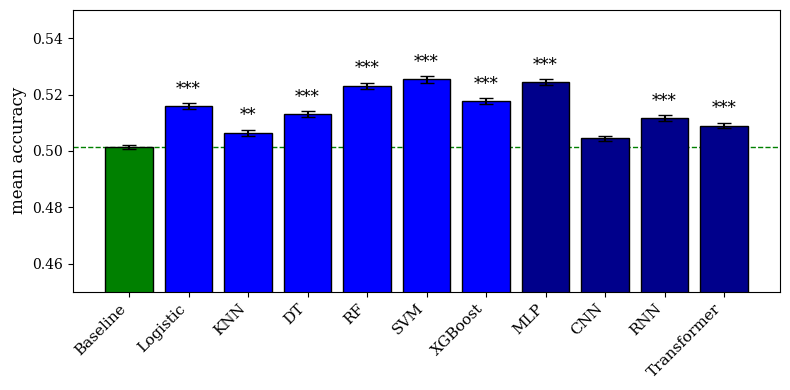

In [13]:
# Create the bar plot for the classification task. 
print('Classification Task: Pooled Cross-Validation Results')
create_bar_plot(df_summary_class, 'accuracy', model_abbreviations_class)

Regression Task: Pooled Cross-Validation Results


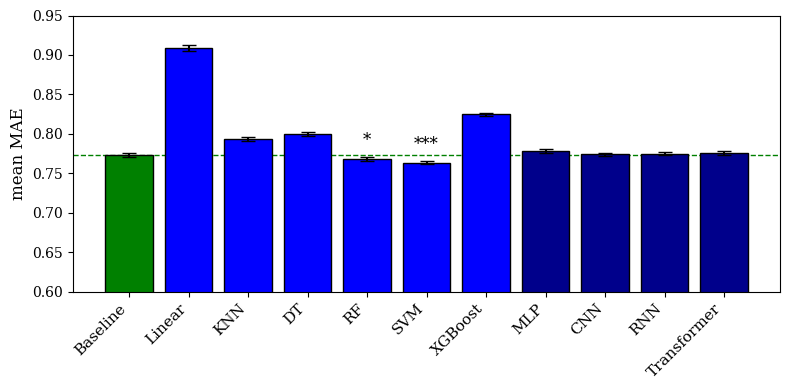

In [14]:
# Create the bar plot for the regression task. 
print('Regression Task: Pooled Cross-Validation Results')
create_bar_plot(df_summary_reg, 'MAE', model_abbreviations_reg)